# 02 Model comparison

            Compare logistic regression, Random Forest and KNN after a fixed
            54-setting search. The reported means are across five outer validation
            folds. Balanced accuracy gives ASD and control recognition equal weight.
            No synthetic sampling, PCA input or threshold optimization was used.

In [1]:
from pathlib import Path
import json
from IPython.display import Markdown, Image, display

current = Path.cwd().resolve()
STUDY = next(p for p in (current, *current.parents)
             if (p / "results/published").is_dir())
RESULTS = STUDY / "results/published"

def read_json(relative):
    path = (RESULTS / relative).resolve()
    if not path.is_relative_to(RESULTS.resolve()) or path.suffix != ".json":
        raise ValueError("Only published JSON summaries may be read")
    return json.loads(path.read_text())

def table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

print("Review mode: included aggregate results only; no training or participant-table access.")

Review mode: included aggregate results only; no training or participant-table access.


| Model | Accuracy | Balanced accuracy | ROC AUC | Sensitivity | Specificity |
| --- | --- | --- | --- | --- | --- |
| logistic regression | 75.1% | 74.8% | 0.823 | 76.1% | 73.4% |
| random forest | 67.1% | 59.3% | 0.725 | 90.8% | 27.7% |
| knn | 63.6% | 57.4% | 0.644 | 82.8% | 31.9% |

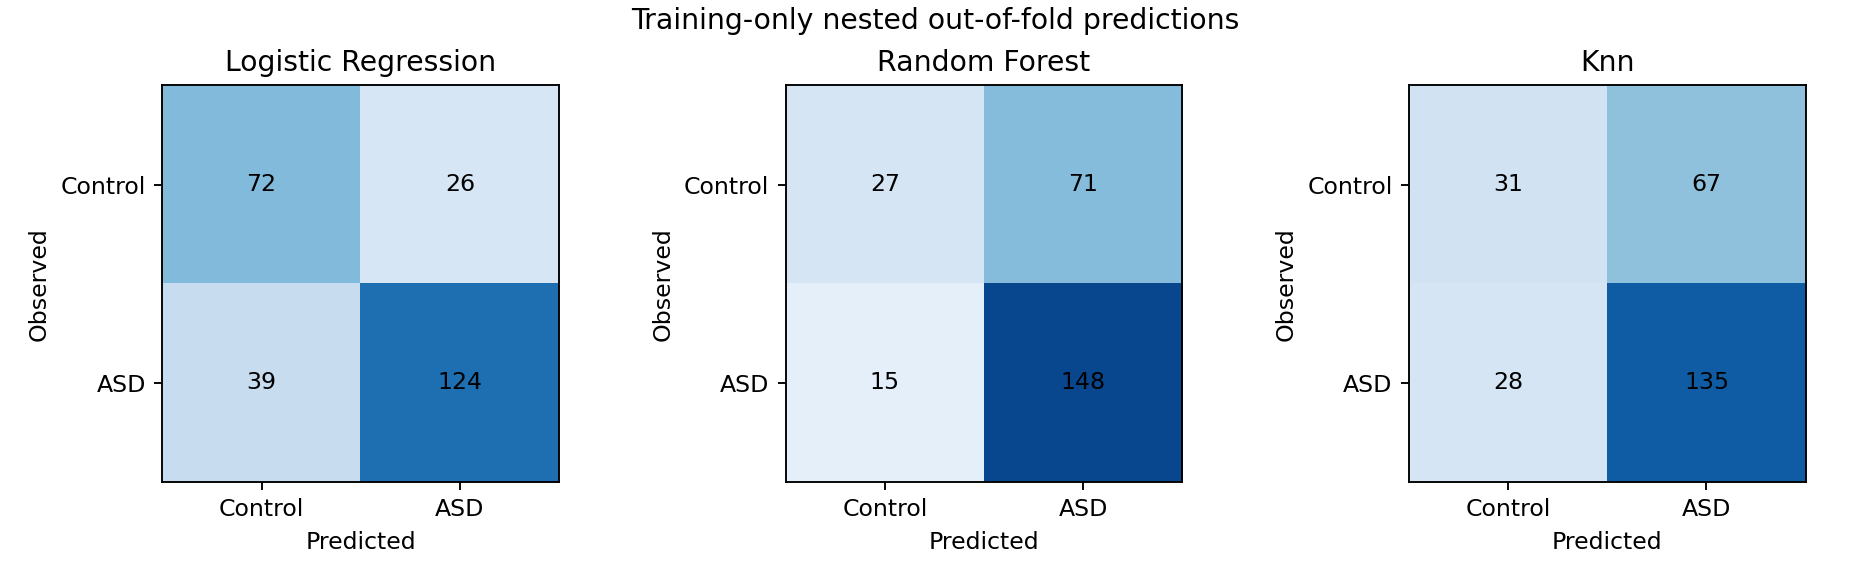

In [2]:
scores = read_json("model_comparison/summary.json")
table(["Model", "Accuracy", "Balanced accuracy", "ROC AUC", "Sensitivity", "Specificity"], [
    [s["model"].replace("_", " "), f'{s["mean_accuracy"]:.1%}',
     f'{s["mean_balanced_accuracy"]:.1%}', f'{s["mean_roc_auc"]:.3f}',
     f'{s["mean_sensitivity"]:.1%}', f'{s["mean_specificity"]:.1%}'] for s in scores])
display(Image(filename=str(RESULTS / "model_comparison/confusion_matrices.png")))

## Interpretation

            Logistic regression remains the strongest of these benchmarks. Its
            result is essentially unchanged from the previous estimate, not a
            newly improved diagnostic score. Across its 261 validation predictions,
            124 ASD records and 72 controls were correctly classified; 39 ASD
            records were missed and 26 controls were labeled ASD.

            False negatives are missed ASD records; false positives are controls
            labeled ASD. Both are errors. Their clinical tradeoff cannot be settled
            by this dataset or accuracy alone. This classifier is not a diagnostic test.

            The mean fold AUC and the pooled out-of-fold AUC are different summaries;
            predictions from separately fitted models need not share calibration.
            [Full model report](../../results/published/model_comparison/RESULTS.md).

            The active pipeline retains the original model without oversampling.
            Temporary experiments are kept separately and are not required steps.